# E1 Structural Misspecification

展示型 notebook：训练 E0 的 SIR workflow，并在 SEIR truth -> SIR inference 的 structural misspecification 下评估 posterior 与 PPC。

In [1]:
import os
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
for candidate in [ROOT, *ROOT.parents]:
    if (candidate / "src").exists():
        ROOT = candidate
        break
else:
    raise RuntimeError("Could not locate project root containing 'src'.")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
OUTPUTS_ROOT = ROOT / "outputs"
print("Project root:", ROOT)
print("Outputs root:", OUTPUTS_ROOT)

from IPython.display import display

from src.config import setup_environment
from src.diagnostics import evaluate_curve_level_ppc
from src.experiments import run_E1_evaluation
from src.plotting import (
    plot_curve_level_ppc_summary,
    plot_e0_overall_figure,
    plot_feature_residuals,
    plot_training_loss,
    plot_truth_vs_median_scatter,
)
from src.simulators import simulate_case_E1, simulate_curve
from src.workflow import train_workflow

Project root: /Users/jijiayi/Documents/25WS/GNN/GNN_Final_Project
Outputs root: /Users/jijiayi/Documents/25WS/GNN/GNN_Final_Project/outputs


In [2]:
missing = []
for pkg in ["bayesflow", "tensorflow", "keras"]:
    try:
        __import__(pkg)
        print(f"[ok] {pkg}")
    except Exception as e:
        missing.append(pkg)
        print(f"[missing] {pkg}: {e}")

if missing:
    print("\nInstall missing packages in the current kernel environment, for example:")
    print("python -m pip install bayesflow==2.0.7 tensorflow==2.17.0 keras==3.9.0")
else:
    print("\nBackend check passed.")

INFO:bayesflow:Using backend 'tensorflow'


[ok] bayesflow
[ok] tensorflow
[ok] keras

Backend check passed.


In [3]:
# Optional install cell.
# Uncomment and run this cell if the backend packages are missing,
# then restart the kernel before continuing.

import sys
print(sys.executable)
# !{sys.executable} -m pip install bayesflow==2.0.7 tensorflow==2.17.0 keras==3.9.0 numpy==1.26.4 pandas==2.3.3 scipy==1.15.3 matplotlib==3.8.4 seaborn

/opt/anaconda3/envs/bayesflow311/bin/python


bayesflow: 2.0.7
tensorflow: 2.17.0
keras: 3.9.0
numpy: 1.26.4
pandas: 2.3.3
scipy: 1.15.3
matplotlib: 3.8.4


INFO:bayesflow:Building dataset from simulator instance of LambdaSimulator.
INFO:bayesflow:Building on a test batch.


Epoch 1/12
60/60 - 36s - 595ms/step - loss: 2.5441
Epoch 2/12
60/60 - 6s - 103ms/step - loss: 1.4825
Epoch 3/12
60/60 - 6s - 106ms/step - loss: 0.9436
Epoch 4/12
60/60 - 7s - 109ms/step - loss: 0.4041
Epoch 5/12
60/60 - 9s - 156ms/step - loss: 0.1514
Epoch 6/12
60/60 - 7s - 120ms/step - loss: -1.6706e-01
Epoch 7/12
60/60 - 8s - 127ms/step - loss: -4.1431e-01
Epoch 8/12
60/60 - 7s - 110ms/step - loss: -5.3902e-01
Epoch 9/12
60/60 - 8s - 136ms/step - loss: -7.0491e-01
Epoch 10/12
60/60 - 7s - 110ms/step - loss: -8.0065e-01
Epoch 11/12
60/60 - 7s - 114ms/step - loss: -8.9503e-01
Epoch 12/12
60/60 - 7s - 114ms/step - loss: -9.4798e-01


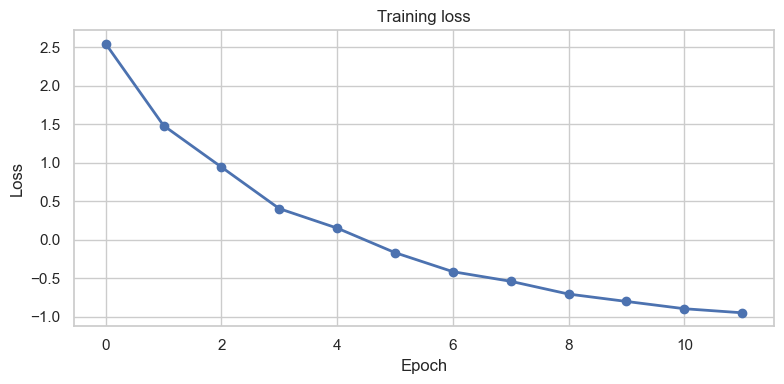

In [4]:
setup_environment(seed=42)
workflow_E0, history_E0 = train_workflow(seed=42)
plot_training_loss(history_E0)

In [5]:
case_df, recovery_df, coverage_df, feature_case_df, feature_summary_df = run_E1_evaluation(
    workflow=workflow_E0,
    n_test=100,
    num_posterior_samples=2000,
    n_ppc_draws=100,
    seed=2026,
)

display(recovery_df.round(4))
display(coverage_df.round(4))
display(feature_summary_df.round(4))

,quantity,bias_mean_est,bias_median_est,MAE_median_est,RMSE_median_est,corr_truth_vs_median,avg_post_std
0,beta,-0.2011,-0.2065,0.2246,0.2657,0.7529,0.0492
1,gamma,-0.0445,-0.0401,0.0602,0.0810,0.8342,0.0472
2,R0,-0.8253,-0.8303,0.8895,1.7243,0.9393,0.1882


,quantity,nominal_50,empirical_50,diff_50,nominal_90,empirical_90,diff_90,avg_width50,avg_width90
0,beta,0.5,0.07,-0.43,0.9,0.30,-0.60,0.0689,0.1593
1,gamma,0.5,0.25,-0.25,0.9,0.56,-0.34,0.0685,0.1535
2,R0,0.5,0.10,-0.40,0.9,0.41,-0.49,0.2478,0.6130


,feature,nominal_50,empirical_50,diff_50,nominal_90,empirical_90,diff_90,bias_mean_pred,bias_median_pred,MAE_median_pred,RMSE_median_pred,avg_pred_std,avg_width50,avg_width90
0,peak_time,0.5,0.61,0.11,0.9,0.92,0.02,-1.6645,-2.3000,7.0900,10.7210,8.9639,14.3675,27.3145
1,peak_height,0.5,0.50,0.00,0.9,0.86,-0.04,-0.0113,-0.0124,0.0155,0.0210,0.0200,0.0250,0.0618
2,cumulative_infected,0.5,0.71,0.21,0.9,0.97,0.07,-0.0905,-0.1295,0.1810,0.2876,0.4531,0.5256,1.3824
3,early_growth_slope,0.5,0.48,-0.02,0.9,0.86,-0.04,0.0006,0.0006,0.0021,0.0027,0.0025,0.0033,0.0080


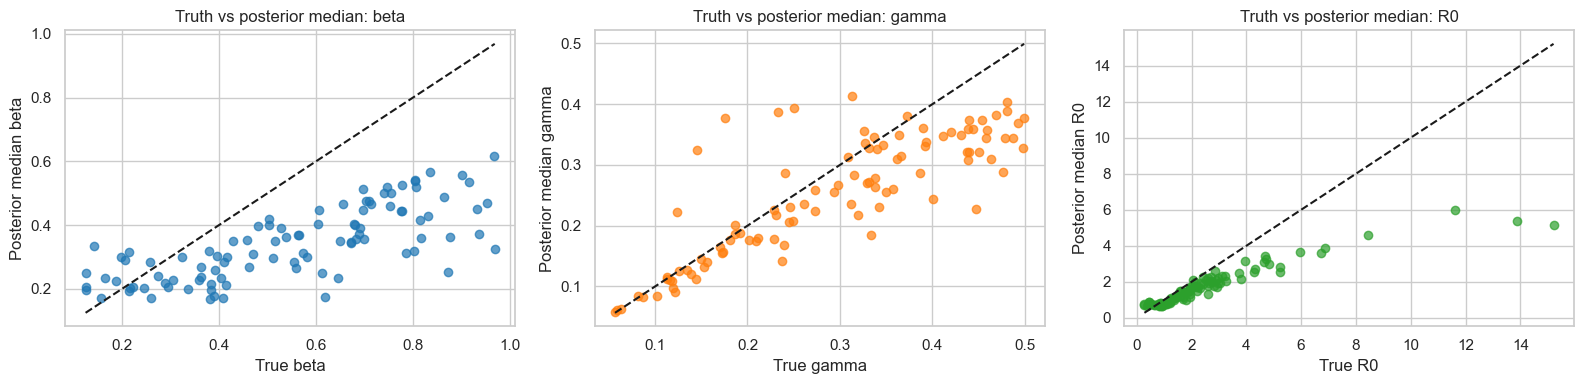

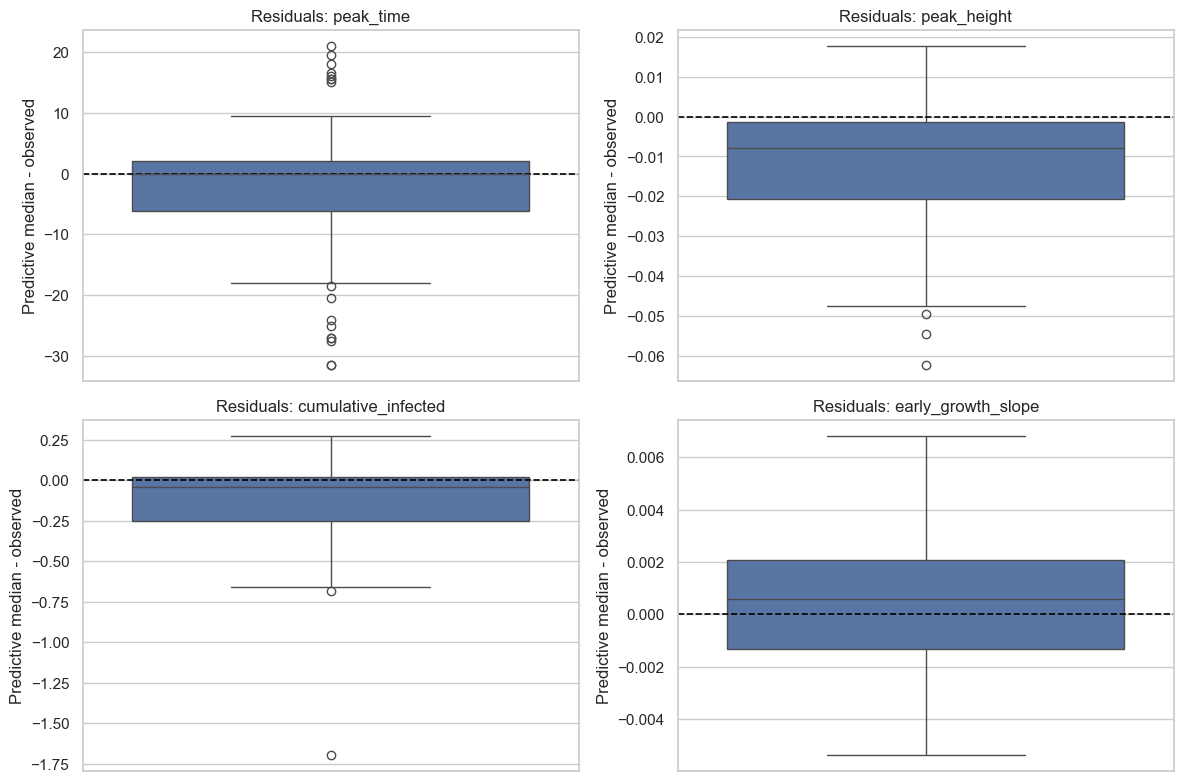

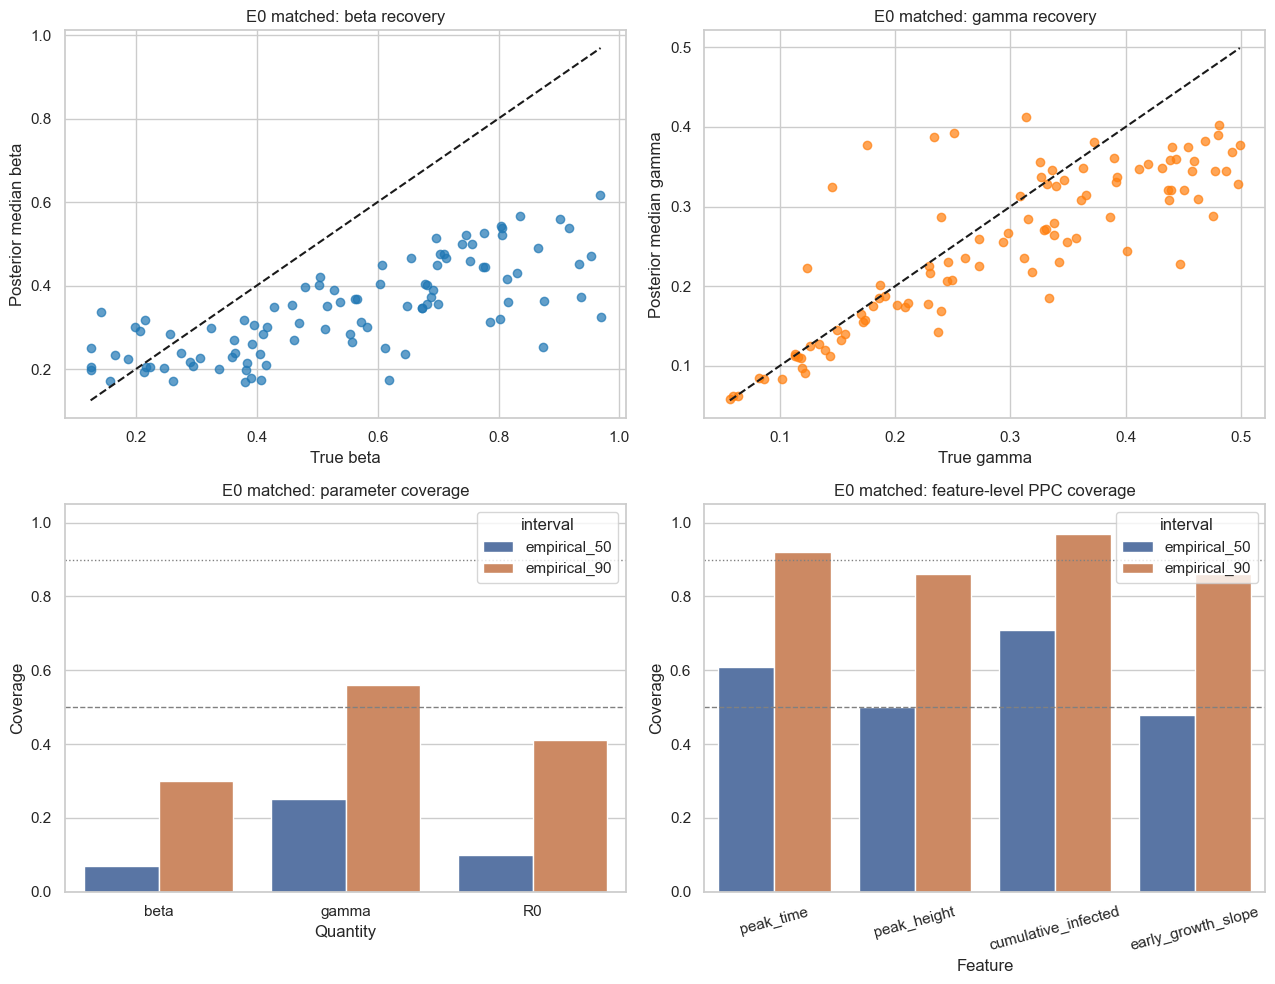

In [6]:
plot_truth_vs_median_scatter(case_df)
plot_feature_residuals(feature_case_df)
plot_e0_overall_figure(
    case_df,
    coverage_df,
    feature_summary_df,
    out_path=str(OUTPUTS_ROOT / "E1" / "E1_structural_overall_figure.png"),
)

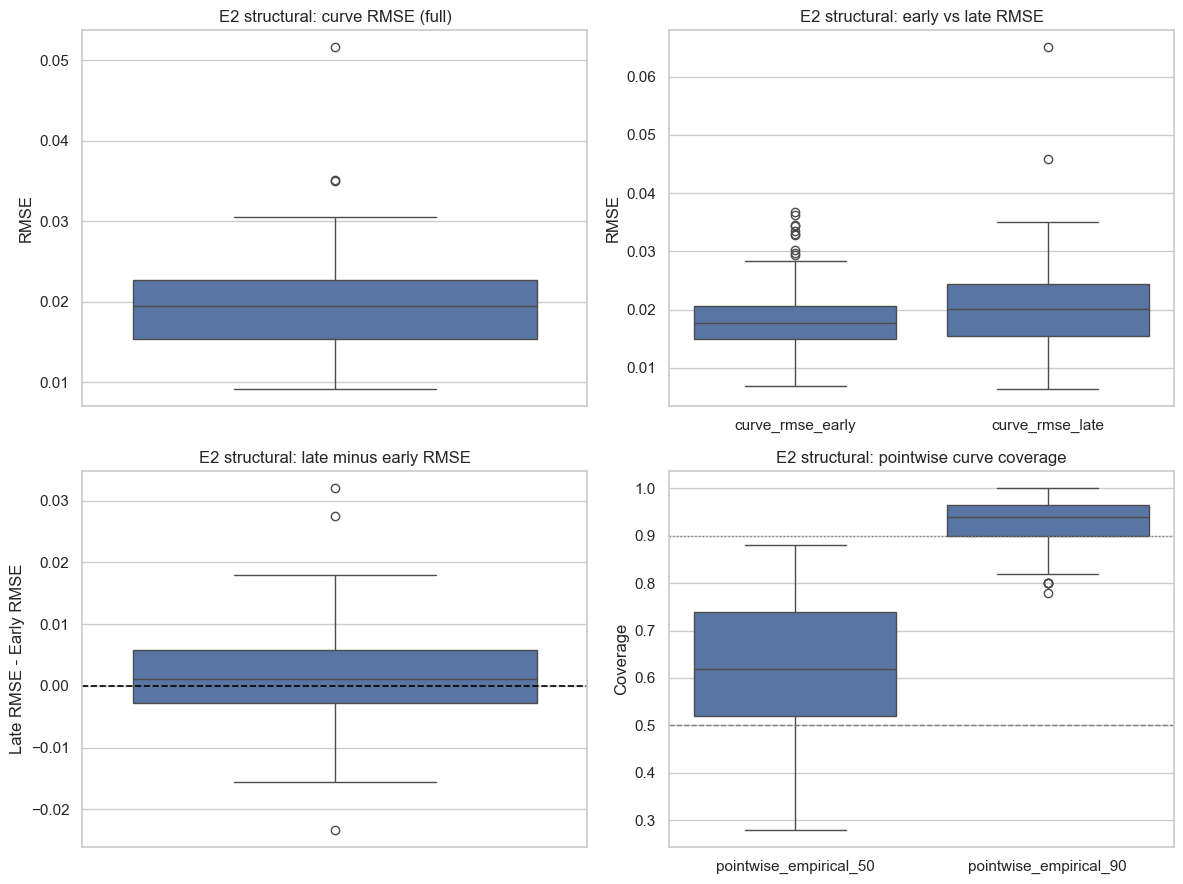

,metric,mean,std,median,q05,q95
0,pointwise_empirical_50,0.6232,0.1438,0.6200,0.3790,0.8210
1,pointwise_empirical_90,0.9292,0.0556,0.9400,0.8190,1.0000
2,curve_bias_full,-0.0050,0.0048,-0.0047,-0.0119,0.0008
3,curve_mae_full,0.0153,0.0054,0.0153,0.0078,0.0226
4,curve_rmse_full,0.0199,0.0062,0.0195,0.0115,0.0287
5,curve_bias_early,-0.0044,0.0048,-0.0039,-0.0156,0.0020
6,curve_mae_early,0.0147,0.0055,0.0143,0.0079,0.0274
7,curve_rmse_early,0.0187,0.0063,0.0177,0.0106,0.0331
8,curve_bias_late,-0.0056,0.0082,-0.0047,-0.0160,0.0050
9,curve_mae_late,0.0159,0.0072,0.0157,0.0074,0.0260


In [7]:
curve_case_df, curve_summary_df = evaluate_curve_level_ppc(
    workflow=workflow_E0,
    case_simulator=simulate_case_E1,
    predictive_curve_simulator=simulate_curve,
    n_test=100,
    num_posterior_samples=1000,
    n_ppc_draws=100,
    seed=2026,
    split_frac=0.5,
)
plot_curve_level_ppc_summary(
    curve_case_df,
    severity_label="structural",
    out_dir=str(OUTPUTS_ROOT / "E1" / "curve_level"),
)
display(curve_summary_df.round(4))

In [8]:
E1_OUTPUT_DIR = OUTPUTS_ROOT / "E1"
E1_CURVE_DIR = E1_OUTPUT_DIR / "curve_level"
os.makedirs(E1_OUTPUT_DIR, exist_ok=True)
os.makedirs(E1_CURVE_DIR, exist_ok=True)
case_df.to_csv(E1_OUTPUT_DIR / "E1_case_level.csv", index=False)
recovery_df.to_csv(E1_OUTPUT_DIR / "E1_recovery_summary.csv", index=False)
coverage_df.to_csv(E1_OUTPUT_DIR / "E1_coverage_summary.csv", index=False)
feature_case_df.to_csv(E1_OUTPUT_DIR / "E1_ppc_feature_case_level.csv", index=False)
feature_summary_df.to_csv(E1_OUTPUT_DIR / "E1_ppc_feature_summary.csv", index=False)
curve_case_df.to_csv(E1_CURVE_DIR / "E1_curve_case_level.csv", index=False)
curve_summary_df.to_csv(E1_CURVE_DIR / "E1_curve_summary.csv", index=False)
print("Saved E1 outputs.")

Saved E1 outputs.
